In [1]:
from qdrant_client import QdrantClient
import os
import csv
from dotenv import load_dotenv
from collections import defaultdict, Counter
from itertools import combinations
import re
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
load_dotenv()

True

In [14]:
# Collecting cases from Qdrant
def collect_diagnosis_data():
    print("[DEBUG] Starting Qdrant client...")

    # --- Configure client ---
    client = QdrantClient(
        url=os.getenv("QDRANT_URL"),
        api_key=os.getenv("QDRANT_API_KEY")
    )

    COLLECTION = "medical_case_texts"
    print(f"[DEBUG] Scanning all points in collection '{COLLECTION}'...")

    offset = None
    total_points = 0

    # Track counts and case IDs
    diagnosis_counts = Counter()
    diagnosis_cases = defaultdict(list)

    while True:
        points, offset = client.scroll(
            collection_name=COLLECTION,
            with_payload=["Summary_Box_First_Line", "case_id"],
            with_vectors=False,
            limit=1000,
            offset=offset
        )

        if not points:
            break

        total_points += len(points)

        for p in points:
            payload = p.payload or {}
            diagnosis = payload.get("Summary_Box_First_Line")
            case_id = payload.get("case_id")

            if diagnosis:
                diagnosis = diagnosis.strip()
                diagnosis_counts[diagnosis] += 1

                # Case ID must be digits (e.g., 001 → 1)
                if case_id and str(case_id).isdigit():
                    diagnosis_cases[diagnosis].append(str(case_id))
                else:
                    digits = re.findall(r"\d+", str(case_id or ""))
                    if digits:
                        diagnosis_cases[diagnosis].append(digits[0])

        if offset is None:
            break

        print(f"[DEBUG] Processed {total_points} points so far...")

    print(f"[DEBUG] Completed scroll. Total points processed: {total_points}")
    print(f"[DEBUG] Found {len(diagnosis_counts)} unique diagnoses.")

    # --- Build pandas DataFrame ---
    records = []
    for diagnosis, count in diagnosis_counts.most_common():
        case_list = sorted(set(diagnosis_cases[diagnosis]))
        records.append({
            "Diagnosis": diagnosis,
            "Count": count,
            "Cases": case_list
        })

    data = pd.DataFrame(records)
    print(f"[SUCCESS] Created DataFrame with {len(data)} rows.")
    return data

# Since there are too many repetitive cases that having the same group of diseases (ex: fever -> Yellow fever, African Tick-Bite Fever,...),
# we will merge it by names first (as I don't have many experience in diseases) using longest subsequence

# Helper function: Longest Common Substring
def longest_common_substring(s1, s2):
    """
    Return the longest valid common word or phrase between s1 and s2.
    - Only considers whole words (split by spaces)
    - Ignores very short or generic words from a blacklist
    """
    s1 = s1.lower().strip()
    s2 = s2.lower().strip()

    words1 = re.findall(r"\b[a-zA-Z]+\b", s1)
    words2 = re.findall(r"\b[a-zA-Z]+\b", s2)

    blacklist = {
        "infected", "infection", "disease", "case", "syndrome", "of", "the",
        "and", "with", "without", "in", "on", "a", "an", "at", "by",
        "patient", "unknown", "clinical", "finding", "history", "condition",
        "human", "african", "bite", "unknown"
    }

    common_phrases = []

    # single-word overlaps
    for w1 in words1:
        if w1 in words2 and w1 not in blacklist:
            common_phrases.append(w1)

    # multiword phrase overlaps (exact phrases)
    for i in range(len(words1) - 1):
        phrase1 = f"{words1[i]} {words1[i+1]}"
        if phrase1 in " ".join(words2) and all(w not in blacklist for w in phrase1.split()):
            common_phrases.append(phrase1)

    if not common_phrases:
        return ""

    common_phrases = sorted(common_phrases, key=len, reverse=True)
    for phrase in common_phrases:
        if len(phrase) >= 3 and phrase not in blacklist:
            return phrase
    return ""



# Merge similar diagnoses and add “Common” column
def merge_similar_diagnoses(df):
    """
    Takes a DataFrame with columns ['Diagnosis', 'Count', 'Cases'].
    Returns a new DataFrame with an additional column 'Common',
    where similar diagnoses are flagged by shared substrings.
    """
    diagnoses = df.copy()
    n = len(diagnoses)
    common_map = [""] * n

    print(f"[DEBUG] Comparing {n} (supposedly unique) diagnoses to find shared terms...")

    for (i, row_i), (j, row_j) in combinations(diagnoses.iterrows(), 2):
        d1 = row_i["Diagnosis"].strip()
        d2 = row_j["Diagnosis"].strip()
        lcs = longest_common_substring(d1, d2)

        if lcs and len(lcs) >= 4:
            common_map[i] = lcs
            common_map[j] = lcs

    diagnoses["Common"] = common_map

    merged = diagnoses[diagnoses["Common"] != ""]
    print(f"[SUCCESS] Found {len(merged)} diagnoses sharing common substrings.")
    print("[INFO] Example 5 grouped diagnoses:")
    for _, r in merged.head(5).iterrows():
        print(f" - {r['Diagnosis']} to {r['Common']}")

    return diagnoses

# Group diagnoses by shared “Common” and aggregate
def group_common_diagnoses(df):
    """
    Groups diagnoses that share the same 'Common' substring.
    Produces a summarized DataFrame with merged counts and case IDs.

    Rules:
    - For each common group, the 'Diagnosis' becomes the group name.
    - 'Common' column lists all other diagnosis names in that group.
    - 'Count' is the total of all merged rows.
    - 'Cases' concatenates and deduplicates all case IDs.
    """

    # Make a copy to avoid modifying the original
    df = df.copy()

    # Separate rows that have and don’t have common labels
    grouped = df[df["Common"] != ""]
    standalone = df[df["Common"] == ""]

    if grouped.empty:
        print("[WARN] No 'Common' groups found — returning original DataFrame.")
        return df

    # --- Group by the 'Common' term ---
    agg_records = []
    for group_name, group_df in grouped.groupby("Common"):
        all_diagnoses = sorted(set(group_df["Diagnosis"].tolist()))
        all_cases = sorted({case for cases in group_df["Cases"] for case in cases})
        total_count = int(group_df["Count"].sum())

        agg_records.append({
            "Diagnosis": group_name,      # Use the shared group term as label
            "Count": total_count,         # Sum of all counts in group
            "Cases": all_cases,           # Combined case list
            "Common": all_diagnoses       # List of merged diagnosis names
        })

    # Convert aggregated groups into a DataFrame
    grouped_df = pd.DataFrame(agg_records)

    # Combine with standalone (non-grouped) diagnoses
    final_df = pd.concat([standalone, grouped_df], ignore_index=True)

    # Sort for readability
    final_df = final_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

    print(f"[SUCCESS] Aggregated {len(grouped_df)} grouped diagnoses.")
    print(f"[INFO] Final table has {len(final_df)} total entries.")

    return final_df

In [4]:
# Check: Begin querying data first
data = collect_diagnosis_data()
data.head(10)

[DEBUG] Starting Qdrant client...
[DEBUG] Scanning all points in collection 'medical_case_texts'...
[DEBUG] Completed scroll. Total points processed: 93
[DEBUG] Found 90 unique diagnoses.
[SUCCESS] Created DataFrame with 90 rows.


,Diagnosis,Count,Cases
0,Melioidosis,2,"[15, 32]"
1,Filoviral Diseases,2,"[1, 53]"
2,Brucellosis,2,"[76, 81]"
3,Neurocysticercosis,1,[38]
4,Yellow Fever,1,[93]
5,Loiasis,1,[28]
6,Tuberculosis in HIV-Infected Patients,1,[33]
7,Measles,1,[31]
8,Cerebral Malaria and Malarial Retinopathy,1,[4]
9,Kaposi’s Sarcoma,1,[59]


In [5]:
# Check: Merging similar cases and save to a .csv file
data = merge_similar_diagnoses(data)
data.to_csv("diagnosis_counts_merged.csv", index=False)
data.head(10)

[DEBUG] Comparing 90 (supposedly unique) diagnoses to find shared terms...
[INFO] Found 30 diagnoses sharing common substrings.
[INFO] Example 5 grouped diagnoses:
 - Neurocysticercosis to neurocysticercosis
 - Yellow Fever to fever
 - Tuberculosis in HIV-Infected Patients to tuberculosis
 - Cerebral Malaria and Malarial Retinopathy to malarial
 - Knowlesi Malaria to malaria


,Diagnosis,Count,Cases,Common
0,Melioidosis,2,"[15, 32]",
1,Filoviral Diseases,2,"[1, 53]",
2,Brucellosis,2,"[76, 81]",
3,Neurocysticercosis,1,[38],neurocysticercosis
4,Yellow Fever,1,[93],fever
5,Loiasis,1,[28],
6,Tuberculosis in HIV-Infected Patients,1,[33],tuberculosis
7,Measles,1,[31],
8,Cerebral Malaria and Malarial Retinopathy,1,[4],malarial
9,Kaposi’s Sarcoma,1,[59],


In [6]:
# Check: Check for all grouped diagnosis
data["Common"].unique()

array(['', 'neurocysticercosis', 'fever', 'tuberculosis', 'malarial',
       'malaria', 'acute', 'schistosomiasis', 'leishmaniasis',
       'meningitis', 'cerebral', 'cutaneous'], dtype=object)

In [ ]:
# Check: Check for different grouped diagnosis
cond = data["Common"] == 'malaria'
data.loc[cond,:]

,Diagnosis,Count,Cases,Common
12,Knowlesi Malaria,1,[92],malaria
43,Malaria,1,[22],malaria


In [16]:
tidy = group_common_diagnoses(data)
tidy.to_csv("diagnosis_final.csv", index=False)
tidy.head(20)

[SUCCESS] Aggregated 11 grouped diagnoses.
[INFO] Final table has 71 total entries.


,Diagnosis,Count,Cases,Common
0,fever,7,"[13, 52, 54, 74, 87, 88, 93]","[African Tick-Bite Fever, Bartonellosis – Oroy..."
1,meningitis,5,"[16, 3, 35, 64, 85]","[Acute Bacterial Meningitis, Cryptococcal Meni..."
2,acute,3,"[20, 48, 77]","[Acute Arboviral Infection, Acute Schistosomia..."
3,tuberculosis,3,"[11, 33, 66]","[Spinal Tuberculosis (Pott’s Disease), Tubercu..."
4,Melioidosis,2,"[15, 32]",
5,Filoviral Diseases,2,"[1, 53]",
6,Brucellosis,2,"[76, 81]",
7,schistosomiasis,2,"[57, 7]","[Genitourinary Schistosomiasis, Hepatosplenic ..."
8,neurocysticercosis,2,"[38, 82]","[Neurocysticercosis, Subarachnoid Neurocystice..."
9,malaria,2,"[22, 92]","[Knowlesi Malaria, Malaria]"


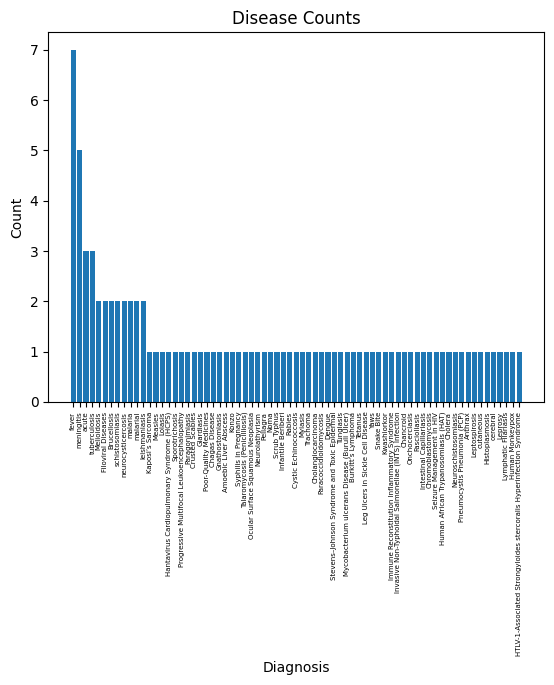

In [32]:
plt.bar(tidy["Diagnosis"], tidy["Count"])
plt.xticks(rotation=90, fontsize= 5)  # Rotate x-axis labels vertically
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.title("Disease Counts")
plt.show()

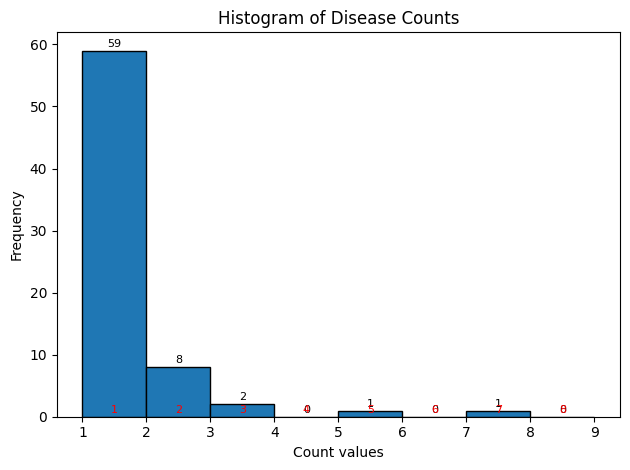

In [42]:
# Histogram
counts, bins, patches = plt.hist(tidy["Count"], bins=[i for i in range(1,10)], edgecolor='black')

# Add labels at bottom (bin count) and top (total frequency)
for i in range(len(counts)):
    # Coordinates for text placement
    x = (bins[i] + bins[i+1]) / 2  # middle of each bar
    y_top = counts[i]
    
    # Show frequency at top (0.3 is offset to slightly move the text away from the bar edge)
    plt.text(x, y_top + 0.3, str(int(y_top)), ha='center', va='bottom', fontsize=8, color='black')

    # Show bin label at bottom (0.3 is offset to slightly move the text away from the bar edge)
    plt.text(x, 0.3, str(int(bins[i])), ha='center', va='bottom', fontsize=8, color='red')

plt.xlabel("Count values")
plt.ylabel("Frequency")
plt.title("Histogram of Disease Counts")
plt.tight_layout()
plt.show()


In [17]:
tidy.describe()

,Count
count,71.000000
mean,1.309859
std,0.934903
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,7.000000
